In [1]:
import kagglehub
import os, glob
from pathlib import Path

# Télécharger / charger le dataset
path = kagglehub.dataset_download("msarmi9/food101tiny")
print("Path to dataset files:", path)

# Vérifier les images dans le dossier
root = Path(path)
img_paths = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    img_paths.extend(glob.glob(str(root / "**" / ext), recursive=True))

print(f"Nombre total d'images trouvées: {len(img_paths)}")


100%|██████████| 96.1M/96.1M [00:01<00:00, 74.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/msarmi9/food101tiny/versions/1
Nombre total d'images trouvées: 2000


In [2]:
from PIL import Image
import numpy as np
import random

# Sélectionner une image au hasard
sample_path = random.choice(img_paths)
img = Image.open(sample_path).convert("RGB")
arr = np.array(img)

print("Chemin:", sample_path)
print("Taille (PIL):", img.size, "-> (largeur, hauteur)")
print("Shape NumPy:", arr.shape, "-> (hauteur, largeur, canaux)")


Chemin: /root/.cache/kagglehub/datasets/msarmi9/food101tiny/versions/1/data/food-101-tiny/train/apple_pie/1272778.jpg
Taille (PIL): (512, 512) -> (largeur, hauteur)
Shape NumPy: (512, 512, 3) -> (hauteur, largeur, canaux)


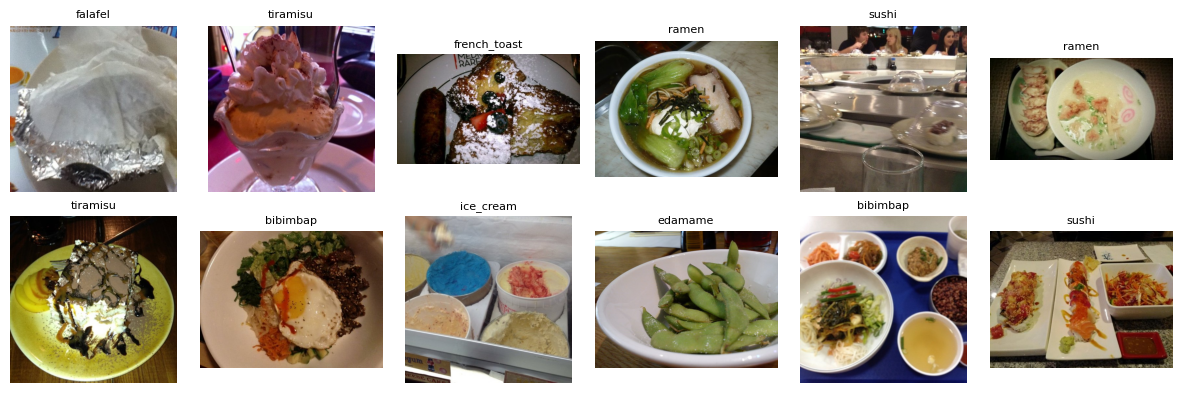

In [3]:
import matplotlib.pyplot as plt

def show_grid(paths, n=12, cols=6):
    selected = random.sample(paths, n)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols*2, rows*2))
    for i, p in enumerate(selected, 1):
        im = Image.open(p).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(im)
        plt.axis("off")
        plt.title(Path(p).parent.name, fontsize=8)
    plt.tight_layout()
    plt.show()

show_grid(img_paths, n=12, cols=6)


In [4]:
arr_float = arr.astype(np.float32) / 255.0
print("Type:", arr_float.dtype)
print("Valeurs min/max:", arr_float.min(), arr_float.max())


Type: float32
Valeurs min/max: 0.0 1.0


In [5]:
# Global
mean_global = arr_float.mean()
std_global = arr_float.std()

# Par canal
mean_per_channel = arr_float.reshape(-1, 3).mean(axis=0)
std_per_channel = arr_float.reshape(-1, 3).std(axis=0)

print("Moyenne globale:", mean_global)
print("Écart-type global:", std_global)
print("Moyennes (R,G,B):", mean_per_channel)
print("Écarts-types (R,G,B):", std_per_channel)


Moyenne globale: 0.53995293
Écart-type global: 0.30056885
Moyennes (R,G,B): [0.7605218 0.5133368 0.3450205]
Écarts-types (R,G,B): [0.21366823 0.25899425 0.26588327]
